In [141]:
from pathlib import Path
import sys

# Make repo root importable (so `import main` works)
repo_root = Path.cwd().parent  # notebook dir -> project root
sys.path.insert(0, str(repo_root))

from main import reimport
import warnings
warnings.filterwarnings('ignore')
reimport()

from Steady_state_equilibrium.SS_Solver import SteadyStateEquilibrium
from Calibration.Labour_func import (build_target_labour_profile, calibrate_chi, update_beta_from_euler,
                                    build_cons_profile, calibrate_chi_beta, calibrate_chi_beta_nested)

import numpy as np
import pandas as pd
import scipy.interpolate as si
from matplotlib import pyplot as plt

## Демография

In [3]:
omega = pd.read_excel(
    '../Data/total_pop.xlsx'
) # in thousands

omega.set_index('Year', inplace=True)
omega /= 1000 # now in mils
omega.head()

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,
2024,1.277417,1.312895,1.380561,1.446116,1.487208,1.567881,1.670708,1.810267,1.930952,1.949820,...,0.140585,0.126703,0.107781,0.087376,0.066252,0.048631,0.032987,0.021349,0.013078,0.016232
2025,1.246285,1.271581,1.308049,1.376177,1.442105,1.483526,1.564484,1.667557,1.807322,1.928187,...,0.127439,0.115805,0.102549,0.085620,0.068076,0.050547,0.036274,0.024023,0.015157,0.020228
2026,1.224295,1.246173,1.271931,1.308417,1.376515,1.442405,1.483793,1.564708,1.667729,1.807435,...,0.148059,0.105124,0.093856,0.081592,0.066803,0.052020,0.037760,0.026459,0.017086,0.024442
2027,1.210562,1.230467,1.252234,1.277520,1.313540,1.381201,1.446697,1.487726,1.568304,1.671013,...,0.177382,0.122317,0.085336,0.074790,0.063772,0.051130,0.038931,0.027589,0.018855,0.028696
2028,1.199379,1.216619,1.236402,1.257707,1.282536,1.318133,1.385408,1.450549,1.491254,1.571531,...,0.212148,0.146734,0.099436,0.068107,0.058541,0.048891,0.038321,0.028490,0.019689,0.032850


In [4]:
def get_mort(totpers):
    data = pd.read_excel('../Data/death_probability.xlsx')
    data.set_index('Year', inplace=True)
    mort = pd.DataFrame(index=data.index, columns=np.arange(totpers)+1)
    for i, year in enumerate(data.index):
        mort_data = data.iloc[i, :]
        mort_data.loc[-1] = 0.
        mort_data.loc[-2] = 0.
        mort_data.loc[totpers+1] = 1.
        mort_data.loc[totpers+2] = 1.

        age_midp = mort_data.index.values

        fit_mort = si.interp1d(age_midp, mort_data, kind='cubic', bounds_error=False, fill_value=0)

        age_model = np.linspace(100 / totpers, 100, totpers) - (0.5 * 100 / totpers)
        mort_model = fit_mort(age_model)
        fit = fit_mort(np.linspace(0, 100, 1000))

        mort.loc[year] = mort_model
    return mort[(mort >= 0.)&(mort <= 1.)].ffill(axis=1)

In [5]:
rho = get_mort(100)
rho.head()

,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,
2024,0.003242,0.003242,0.003242,0.003242,0.000187,0.001342,0.001802,0.001770,0.001474,0.001144,...,0.653907,0.677657,0.702053,0.730243,0.765375,0.810375,0.863029,0.915987,0.961673,0.992514
2025,0.003108,0.003108,0.003108,0.003108,0.000189,0.001294,0.001734,0.001704,0.001422,0.001110,...,0.651599,0.675440,0.699936,0.728264,0.763605,0.808912,0.861955,0.915320,0.961366,0.992454
2026,0.002977,0.002977,0.002977,0.002977,0.000191,0.001247,0.001667,0.001639,0.001371,0.001076,...,0.648988,0.672903,0.697487,0.725956,0.761526,0.807187,0.860685,0.914530,0.961002,0.992382
2027,0.002857,0.002857,0.002857,0.002857,0.000192,0.001203,0.001606,0.001580,0.001325,0.001044,...,0.646180,0.670175,0.694863,0.723496,0.759323,0.805366,0.859348,0.913700,0.960620,0.992307
2028,0.002736,0.002736,0.002736,0.002736,0.000193,0.001159,0.001544,0.001519,0.001277,0.001011,...,0.643941,0.668056,0.692899,0.721729,0.757805,0.804153,0.858480,0.913171,0.960380,0.992260


<BarContainer object of 101 artists>

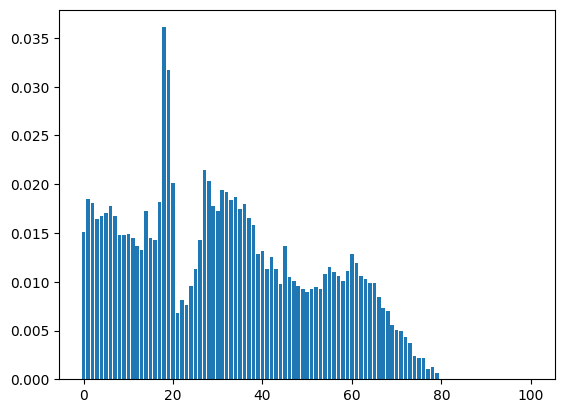

In [6]:
I = pd.read_excel('../Data/age specific migration.xlsx',
                     sheet_name='migration').set_index('Year') # in thousands
I /= 1000 # now in mils
i = pd.read_excel('../Data/age specific migration.xlsx',
                     sheet_name='rate').set_index('age')
i = i['average']
plt.bar(i.index, i)

In [7]:
pops = pd.DataFrame(omega.loc[2025][:-1].values, columns=['omega'], index=range(1, 101))
pops['rho'] = rho.loc[2025].values
pops['i'] = i[:-1]
pops.to_csv('../Data/pops.csv')

## Labour augmentation

In [8]:
def get_tuple_bins(strings):
    groups = []
    for i in strings:
        i = i.replace(' ', '')
        if len(i) <= 5:
            groups.append((int(i[:2]), int(i[3:])))
        else:
            groups.append((int(i[:2]), 999))
    return groups

In [9]:
employment = pd.read_excel('../Data/employment.xlsx', header=1).iloc[-1, 2:]
employ = {group: val/100 for group, val in zip(get_tuple_bins(employment.index), employment.values)}
hours = pd.read_excel('../Data/hours.xlsx', header=2)
hours = {group: val for group, val in zip(get_tuple_bins(hours.iloc[1:, 0]), hours.iloc[1:, -1])}

In [10]:
n_target, ep_profile, hours_profile = build_target_labour_profile(
    ep_by_bin=employ,
    hours_by_bin=hours,
    h_max=100,
    E=20,
    S=100,
    tail_start_age=70,
    tail_zero_age=85,
    left_anchor_offset=6,
    return_components=True
)

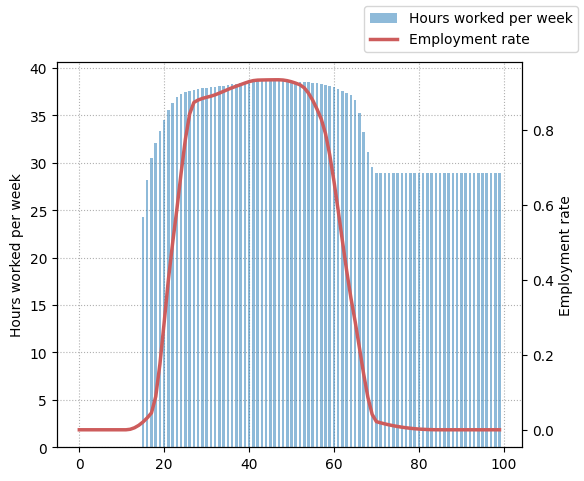

In [11]:
hours_profile[:15] = 0
ep_profile[:12] = 0

fig, ax1 = plt.subplots(figsize=[6,5])

ax2 = ax1.twinx()

ax1.bar(range(len(hours_profile)), hours_profile, color='C0', alpha=0.5,
        label='Hours worked per week', width=.6)
ax2.plot(ep_profile, color='indianred', linewidth=2.5, label='Employment rate')

ax1.set_ylabel('Hours worked per week')
ax2.set_ylabel('Employment rate')

# Grid only on ax1, ":" style, and behind the plots
ax1.grid(True, linestyle=':', zorder=0)
ax1.set_axisbelow(True)

# Make sure ax2 has no grid
ax2.grid(False)

fig.legend()
plt.savefig('/home/eurapartners.local/moiseev.kv/Repositories/tex_Thesis/src/resources/figures/chi_s_profile.png', dpi=300)

In [61]:
reimport()
c_target = build_cons_profile()

## Equilibrium 2025

In [ ]:
from Calibration.Labour_func import update_chi_from_foc


year = 2025
g_n = omega.loc[year].sum() / omega.loc[year-1].sum() - 1
S = 85
R = 62
chi_s = np.ones(S)
chi_s[R:] = 1e12
c_min = (0.0 * 5.6) * (1 - 0.7 * np.exp(-0.054))

params = {
    'A': 1.4,
    'alpha': .39,
    'delta': .05,
    'tau_c': 0.,
    'tau_l': .22,
    'tau_k': 0.,
    'R': R,
    'E': 20,
    'S': S,
    'g_n': g_n,
    'g_y': .054,
    'beta': .905,
    'sigma': 1.97,
    'replacement_rate': .22,
    'ltilde': 1.,
    'b_ellip': .4309,
    'upsilon': 1.7648,
    'h': 0.4,
    #'c_min_wage_share': 0.0,
    'c_min': c_min,
}
# Normalizing population to 1 for convenience
pop_base = omega.iloc[:, :S].sum(axis=1)
omega_norm = omega.div(pop_base, axis=0)
I_norm = I.div(pop_base, axis=0)
rho_norm = rho.loc[year].values[:S]
rho_norm[-1] = 1.

vectors = {
    'omega': omega_norm.loc[year][:-1].values[:S],
    'rho': rho_norm,
    'i_rate': i[:-1].values[:S],
    'I_total': I_norm.loc[year].values,
}

solver_params = {
    'r_guess': 0.1,
    'BQ_guess': .5,
    'tax_guess': .22,
    'policy_mode': 'fix_tax',
    'tax_type': 'tau_l',
    'xi': 0.2,
    'tol': 1e-2,
    'max_iter': 500,
    'debug': False
}
params['beta_s'] = update_beta_from_euler(c_target[:S], solver_params['r_guess'], vectors['rho'], params)
params['chi_s'] = update_chi_from_foc(c_target[:S], 2., .22, n_target[:S], vectors['rho'], params)

reimport()
chi_s_cal, beta_s_cal, ss = calibrate_chi_beta_nested(
    params=params, 
    vectors=vectors,
    n_target=n_target[:S], 
    c_target=c_target[:S],
    n_cycles=50,
    chi_per_beta=3, 
    xi_chi=0.8, 
    xi_beta=0.25,
    chi_tol=1e-3, 
    beta_tol=1e-2,
    ss_solve_kwargs=solver_params, 
    ky_max=8.0, 
    r_floor=-0.02,
    verbose=True,
)

Converged in 21 iterations, Error=0.009100
  guesses: r=0.1465 | BQ=0.2925 | PolVar=1.2923
  implied: r_new=0.1470 | BQ_new=0.2834 | policy_new=1.2912
  aggregates: Y=1.9468 | K=3.8540 | L=0.7247 | C=1.7843 | w=1.6413

  b_R=1.1021, b_S=-0.0000, c_old=3.0016

Converged in 19 iterations, Error=0.008661
  guesses: r=0.1389 | BQ=0.2593 | PolVar=0.8275
  implied: r_new=0.1392 | BQ_new=0.2538 | policy_new=0.8361
  aggregates: Y=1.2610 | K=2.5988 | L=0.4575 | C=1.1957 | w=1.6836

  b_R=4.0378, b_S=0.0000, c_old=1.7942

Converged in 18 iterations, Error=0.008423
  guesses: r=0.1370 | BQ=0.2043 | PolVar=0.6449
  implied: r_new=0.1374 | BQ_new=0.1992 | policy_new=0.6533
  aggregates: Y=0.9851 | K=2.0495 | L=0.3552 | C=0.9339 | w=1.6942

  b_R=3.5087, b_S=-0.0000, c_old=1.3627

Converged in 16 iterations, Error=0.009340
  guesses: r=0.1363 | BQ=0.1743 | PolVar=0.5441
  implied: r_new=0.1367 | BQ_new=0.1692 | policy_new=0.5535
  aggregates: Y=0.8345 | K=1.7431 | L=0.3002 | C=0.7912 | w=1.6985

  

KeyboardInterrupt: 

{'r': np.float64(0.08175732321807651), 'w': np.float64(2.1277337684384228), 'BQ': np.float64(0.10549874770534909), 'X_val': np.float64(0.39496722012296037), 'tau_l': 0.22, 'tau_k': 0.0, 'tau_c': 0.0, 'Y': np.float64(0.5945949248300371), 'K': np.float64(1.7599934107639785), 'L': np.float64(0.1711396279566235), 'C': np.float64(0.5069394304427461), 'c_vec': array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.40683387, 0.45544434, 0.49705761, 0.53299204, 0.56954036,
       0.60470415, 0.63642334, 0.66257377, 0.68459927, 0.70514803,
       0.72384432, 0.74030063, 0.75411735, 0.76644455, 0.77838441,
       0.78944454, 0.7991166 , 0.80687606, 0.81202444, 0.81464304,
       0.8153813 , 0.81491138, 0.81392853, 0.81081603, 0.80431246,
       0.79569541, 0.78628627, 0.7774515

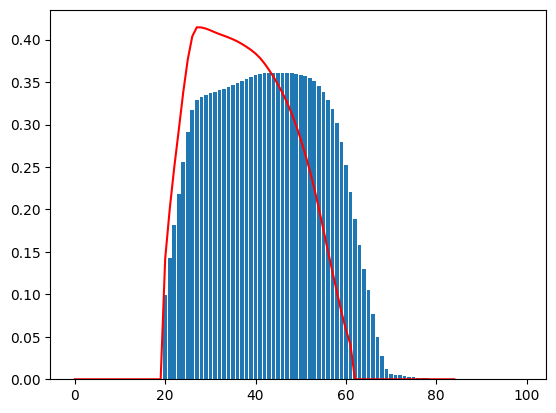

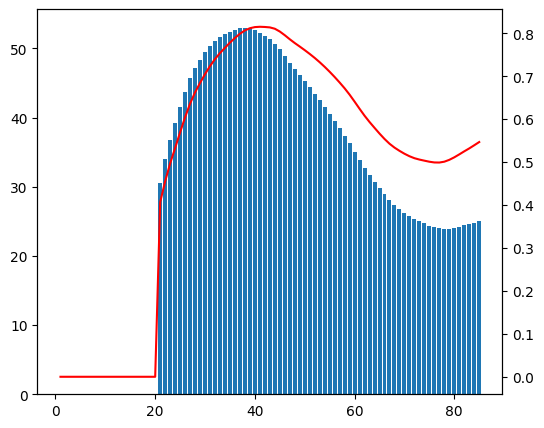

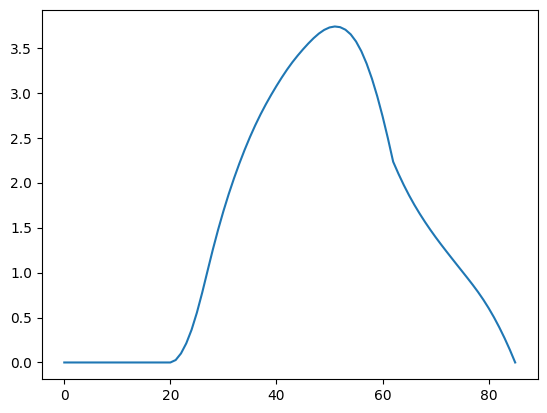

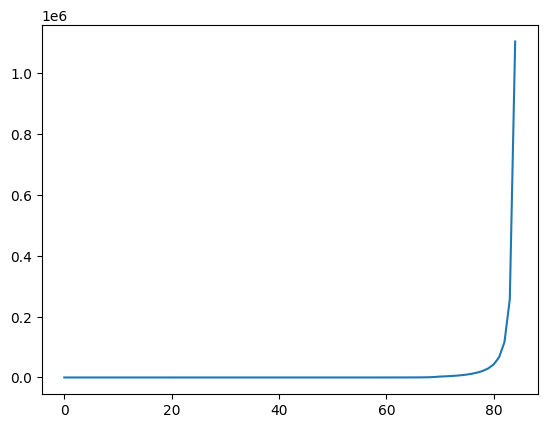

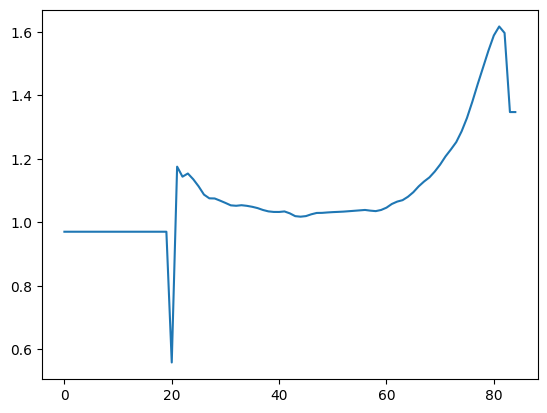

In [159]:
print(ss_results)
plt.plot(ss_results['n_vec'], c='r')
plt.bar(range(0, 100), n_target)
plt.show()

fig, ax1 = plt.subplots(figsize=[6,5])
ax2 = ax1.twinx()
ax1.bar(range(1, S+1), c_target[:S])
ax2.plot(range(1, S+1), ss_results['c_vec'], c='r')
plt.show()

plt.plot(ss_results['b_vec'])
plt.show()

plt.plot(chi_s_cal)
plt.show()

plt.plot(beta_s_cal)